# 09 — Quasi-Experimental & Statistical Analysis

**Phase 11.**

# ⚠️ These are OBSERVATIONAL comparisons, not randomised experiments

**This dataset has no experiment.** There is no treatment flag, no control group, no randomisation,
no holdout, and no record of any intervention. Nobody assigned customers to conditions.

What this notebook does is construct **natural quasi-experiments** — comparisons between groups that
arose on their own in the data — and analyse them with the full statistical apparatus: hypotheses,
significance level, test statistic, p-value, confidence interval and effect size.

### Why the distinction matters, concretely

In a randomised test, assignment is independent of everything else, so a significant difference in
the outcome can be attributed to the treatment. Here, **group membership is chosen by the customer
or determined by circumstance**, so any difference mixes the effect of interest with every
characteristic that differs between the groups.

A worked example from Test 1 below: customers paying by credit card spend more than those paying by
boleto. That difference is real and highly significant. But credit-card holders also differ in
income, region, category preference and risk profile — none of which this dataset measures. The
p-value quantifies **how surely the two groups differ**, not **whether payment method caused the
difference**. No p-value, however small, converts a correlation into a cause.

Section 4 applies the standard partial defence — checking whether each effect survives *within*
observable subgroups — which strengthens a causal reading without establishing it.

### Tests performed

| # | Comparison | Outcome | Test |
|---|---|---|---|
| 1 | Credit card vs boleto | order value | Welch's t-test (+ Mann-Whitney) |
| 2 | Late vs on-time delivery | 1-star review rate | Chi-square test of independence |
| 3 | Late vs on-time first order | repeat purchase | Two-proportion z-test |

**Significance level: α = 0.05** for every test, fixed before analysis.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, str(Path("..").resolve()))
from src.viz import *
apply_style()

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

PROC = Path("..") / "data" / "processed"
fct_orders = pd.read_parquet(PROC / "fct_orders.parquet")
fct_items = pd.read_parquet(PROC / "fct_order_items.parquet")

# The analysis base fixed in Phase 3: delivered orders inside the usable window.
orders = fct_orders[fct_orders.is_delivered & fct_orders.in_window].copy()
items = fct_items[(fct_items.is_delivered == True) & (fct_items.in_window == True)].copy()

print(f"orders   : {len(orders):,}  (delivered, Jan-2017..Aug-2018)")
print(f"items    : {len(items):,}")
print(f"revenue  : R$ {orders.order_revenue.sum():,.2f}")
print(f"customers: {orders.customer_unique_id.nunique():,}")


from scipy import stats

ALPHA = 0.05
print(f"\nsignificance level alpha = {ALPHA}")
print(f"analysis base: {len(orders):,} delivered orders, Jan 2017 - Aug 2018")

orders   : 96,211  (delivered, Jan-2017..Aug-2018)
items    : 109,880
revenue  : R$ 13,181,027.13
customers: 93,104



significance level alpha = 0.05
analysis base: 96,211 delivered orders, Jan 2017 - Aug 2018


## 1. Test 1 — does payment method associate with order value?

### The quasi-experiment

Brazilian e-commerce offers two dominant payment routes: **credit card** (often with instalments)
and **boleto bancário** (a cash/bank voucher paid up front, with no credit facility). Customers
self-select. If access to credit enables larger baskets, credit-card orders should be larger.

### Hypotheses

- **H₀:** mean order value is equal for credit-card and boleto orders — μ_cc = μ_boleto
- **H₁:** the means differ — μ_cc ≠ μ_boleto (two-tailed)
- **α = 0.05**

### Test choice

**Welch's t-test**, not Student's: the two groups have different variances and very different sizes,
and Welch does not assume equal variance. Order value is heavily right-skewed (skew ≈ 9.9), so a
**Mann-Whitney U** test is run alongside as a distribution-free check, plus a test on the log scale.
The Central Limit Theorem makes the t-test's mean estimate reliable at these sample sizes despite
the skew, but agreement across all three is stronger evidence than any one of them.

In [2]:
cc = orders.loc[orders.payment_type == "credit_card", "order_revenue"].dropna()
bo = orders.loc[orders.payment_type == "boleto", "order_revenue"].dropna()

desc = pd.DataFrame({
    "credit_card": [len(cc), cc.mean(), cc.median(), cc.std(), cc.skew()],
    "boleto": [len(bo), bo.mean(), bo.median(), bo.std(), bo.skew()],
}, index=["n", "mean", "median", "std_dev", "skew"])
display(desc.round(3))

print(f"observed difference in means: R$ {cc.mean() - bo.mean():,.2f}")
print(f"observed difference in medians: R$ {cc.median() - bo.median():,.2f}")

,credit_card,boleto
n,"72,619.00","19,140.00"
mean,143.19,121.39
median,89.90,74.90
std_dev,213.04,201.42
skew,9.44,11.82


observed difference in means: R$ 21.80
observed difference in medians: R$ 15.00


In [3]:
t_stat, p_val = stats.ttest_ind(cc, bo, equal_var=False)

n1, n2 = len(cc), len(bo)
v1, v2 = cc.var(ddof=1), bo.var(ddof=1)
se = np.sqrt(v1/n1 + v2/n2)
df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
diff = cc.mean() - bo.mean()
crit = stats.t.ppf(1 - ALPHA/2, df)
ci_low, ci_high = diff - crit*se, diff + crit*se

pooled_sd = np.sqrt(((n1-1)*v1 + (n2-1)*v2) / (n1+n2-2))
cohens_d = diff / pooled_sd

print("WELCH'S TWO-SAMPLE t-TEST")
print(f"  t statistic        : {t_stat:.4f}")
print(f"  degrees of freedom : {df:,.0f}")
print(f"  p-value            : {p_val:.3e}")
print(f"  difference in means: R$ {diff:,.2f}")
print(f"  95% CI for difference: [R$ {ci_low:,.2f}, R$ {ci_high:,.2f}]")
print(f"  Cohen's d          : {cohens_d:.4f}")
print(f"\n  decision: {'REJECT' if p_val < ALPHA else 'FAIL TO REJECT'} H0 at alpha = {ALPHA}")

WELCH'S TWO-SAMPLE t-TEST
  t statistic        : 13.1601
  degrees of freedom : 31,370
  p-value            : 1.894e-39
  difference in means: R$ 21.80
  95% CI for difference: [R$ 18.56, R$ 25.05]
  Cohen's d          : 0.1035

  decision: REJECT H0 at alpha = 0.05


In [4]:
u_stat, p_u = stats.mannwhitneyu(cc, bo, alternative="two-sided")
rank_biserial = 1 - 2*u_stat/(n1*n2)

log_t, log_p = stats.ttest_ind(np.log(cc), np.log(bo), equal_var=False)
geo_ratio = np.exp(np.log(cc).mean() - np.log(bo).mean())

print("ROBUSTNESS — three tests, same conclusion")
print(f"  Welch t-test (means)   : p = {p_val:.3e}")
print(f"  Mann-Whitney U         : U = {u_stat:,.0f}, p = {p_u:.3e}, "
      f"rank-biserial r = {rank_biserial:+.4f}")
print(f"  Welch on log scale     : t = {log_t:.3f}, p = {log_p:.3e}")
print(f"    ratio of geometric means: {geo_ratio:.4f}  "
      f"(credit card {(geo_ratio-1)*100:+.1f}% on a multiplicative scale)")
print("\nAll three reject H0. The result is not an artefact of the skew.")

ROBUSTNESS — three tests, same conclusion
  Welch t-test (means)   : p = 1.894e-39
  Mann-Whitney U         : U = 770,749,262, p = 1.540e-119, rank-biserial r = -0.1090
  Welch on log scale     : t = 23.061, p = 1.181e-116
    ratio of geometric means: 1.1894  (credit card +18.9% on a multiplicative scale)

All three reject H0. The result is not an artefact of the skew.


findfont: Failed to find font weight 600, now using 700.


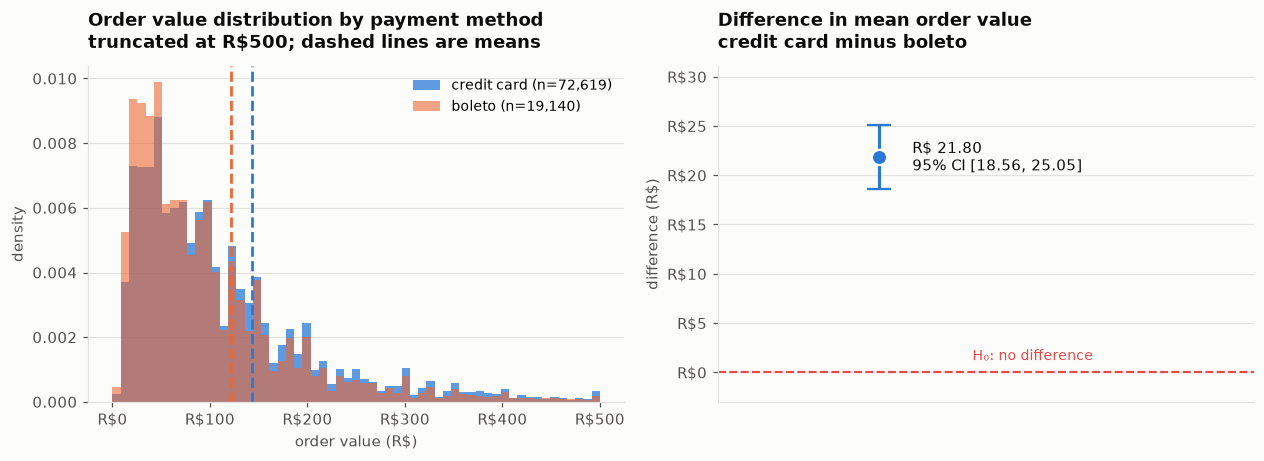

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3))

ax = axes[0]
bins = np.linspace(0, 500, 60)
ax.hist(cc, bins=bins, color=BLUE, alpha=0.75, label=f"credit card (n={n1:,})", density=True)
ax.hist(bo, bins=bins, color=ORANGE, alpha=0.6, label=f"boleto (n={n2:,})", density=True)
ax.axvline(cc.mean(), color=BLUE, linewidth=1.8, linestyle="--")
ax.axvline(bo.mean(), color=ORANGE, linewidth=1.8, linestyle="--")
ax.set_title("Order value distribution by payment method\ntruncated at R$500; dashed lines are means")
ax.set_xlabel("order value (R$)"); ax.set_ylabel("density")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.legend(loc="upper right")
ax.grid(axis="x", visible=False); despine(ax)

ax = axes[1]
ax.errorbar([0], [diff], yerr=[[diff-ci_low], [ci_high-diff]], fmt="o",
            color=BLUE, markersize=10, capsize=8, capthick=2, linewidth=2,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
ax.axhline(0, color=NEG, linewidth=1.4, linestyle="--")
ax.annotate("H\u2080: no difference", xy=(0.35, 0), xytext=(0, 8),
            textcoords="offset points", fontsize=9, color=NEG)
ax.annotate(f"R$ {diff:,.2f}\n95% CI [{ci_low:,.2f}, {ci_high:,.2f}]",
            xy=(0, diff), xytext=(22, 0), textcoords="offset points",
            fontsize=9.5, color=INK, va="center")
ax.set_xlim(-0.6, 1.4); ax.set_xticks([])
ax.set_ylim(min(-3, ci_low - 6), ci_high + 6)
ax.set_title("Difference in mean order value\ncredit card minus boleto")
ax.set_ylabel("difference (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.grid(axis="x", visible=False); despine(ax)

plt.tight_layout(); plt.show()

### Result — statistically overwhelming, practically modest

| Quantity | Value |
|---|---|
| Mean AOV, credit card | **R$143.19** (n = 72,619) |
| Mean AOV, boleto | **R$121.39** (n = 19,140) |
| Difference | **R$21.80** |
| 95% CI | **[R$18.56, R$25.05]** |
| Welch t (df ≈ 31,370) | **13.16** |
| p-value | **1.9 × 10⁻³⁹** |
| Cohen's d | **0.104** |

**H₀ is rejected.** But read the effect size: **Cohen's d = 0.10 is a "small" effect** by the
conventional benchmark (0.2 small, 0.5 medium, 0.8 large) — it is below even that. The two
distributions overlap almost completely; the rank-biserial correlation of −0.109 says that if you
drew one order from each group, the credit-card order would be larger only about 55% of the time.

**This gap between significance and magnitude is the whole lesson of the phase**, and Section 3
quantifies it directly.

## 2. Test 2 — does late delivery associate with poor reviews?

### The quasi-experiment

This is the stronger natural experiment of the two. Delivery lateness is **not chosen by the
customer** — it results from carrier performance, distance, weather and seller dispatch speed. That
makes assignment substantially more exogenous than payment method, though still not random.

### Hypotheses

- **H₀:** the 1-star review rate is independent of whether delivery beat its estimated date
- **H₁:** the two are not independent
- **α = 0.05**
- **Test:** Pearson chi-square test of independence (expected counts far exceed 5 in every cell)

In [6]:
rev = orders.dropna(subset=["review_score"]).copy()
rev["one_star"] = rev.review_score == 1

contingency = pd.crosstab(rev.is_late, rev.one_star)
contingency.index = ["on time / early", "late"]
contingency.columns = ["not 1 star", "1 star"]
display(contingency)

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
n_total = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n_total * (min(contingency.shape) - 1)))

p_late = contingency.loc["late", "1 star"] / contingency.loc["late"].sum()
p_ontime = contingency.loc["on time / early", "1 star"] / contingency.loc["on time / early"].sum()
n_late, n_ontime = contingency.loc["late"].sum(), contingency.loc["on time / early"].sum()

diff_p = p_late - p_ontime
se_p = np.sqrt(p_late*(1-p_late)/n_late + p_ontime*(1-p_ontime)/n_ontime)
ci_p = (diff_p - 1.96*se_p, diff_p + 1.96*se_p)

print("CHI-SQUARE TEST OF INDEPENDENCE")
print(f"  chi-square statistic : {chi2:,.2f}")
print(f"  degrees of freedom   : {dof}")
print(f"  p-value              : {p_chi:.3e}")
print(f"  Cramer's V           : {cramers_v:.4f}")
print(f"\n  1-star rate when late    : {p_late*100:.2f}%  (n = {n_late:,})")
print(f"  1-star rate when on time : {p_ontime*100:.2f}%  (n = {n_ontime:,})")
print(f"  difference               : {diff_p*100:.2f} pp")
print(f"  95% CI for difference    : [{ci_p[0]*100:.2f} pp, {ci_p[1]*100:.2f} pp]")
print(f"  risk ratio               : {p_late/p_ontime:.2f}x")
print(f"\n  decision: {'REJECT' if p_chi < ALPHA else 'FAIL TO REJECT'} H0 at alpha = {ALPHA}")

,not 1 star,1 star
on time / early,82134,5776
late,4120,3538


CHI-SQUARE TEST OF INDEPENDENCE
  chi-square statistic : 12,572.93
  degrees of freedom   : 1
  p-value              : 0.000e+00
  Cramer's V           : 0.3627

  1-star rate when late    : 46.20%  (n = 7,658)
  1-star rate when on time : 6.57%  (n = 87,910)
  difference               : 39.63 pp
  95% CI for difference    : [38.50 pp, 40.76 pp]
  risk ratio               : 7.03x

  decision: REJECT H0 at alpha = 0.05


In [7]:
full = pd.crosstab(rev.is_late, rev.review_score)
full.index = ["on time / early", "late"]
print("FULL 2 x 5 TABLE — all review scores")
display(full)

chi2_full, p_full, dof_full, _ = stats.chi2_contingency(full)
v_full = np.sqrt(chi2_full / (full.values.sum() * min(full.shape[0]-1, full.shape[1]-1)))
print(f"  chi-square = {chi2_full:,.2f}, dof = {dof_full}, p = {p_full:.3e}, Cramer's V = {v_full:.4f}")

pct = full.div(full.sum(axis=1), axis=0) * 100
print("ROW PERCENTAGES")
display(pct.round(2))

FULL 2 x 5 TABLE — all review scores


review_score,1.00,2.00,3.00,4.00,5.00
on time / early,5776,2313,7023,17894,54904
late,3538,602,872,943,1703


  chi-square = 14,236.39, dof = 4, p = 0.000e+00, Cramer's V = 0.3860
ROW PERCENTAGES


review_score,1.00,2.00,3.00,4.00,5.00
on time / early,6.57,2.63,7.99,20.35,62.45
late,46.20,7.86,11.39,12.31,22.24


findfont: Failed to find font weight 600, now using 700.


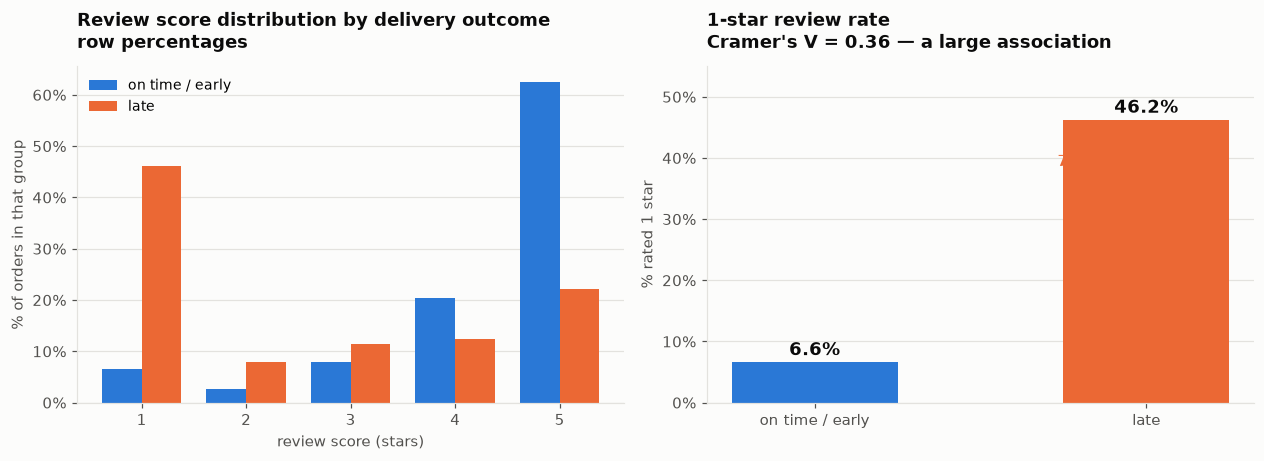

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3))

ax = axes[0]
x = np.arange(5)
w = 0.38
ax.bar(x - w/2, pct.loc["on time / early"], width=w, color=BLUE, label="on time / early")
ax.bar(x + w/2, pct.loc["late"], width=w, color=ORANGE, label="late")
ax.set_xticks(x); ax.set_xticklabels([1, 2, 3, 4, 5])
ax.set_title("Review score distribution by delivery outcome\nrow percentages")
ax.set_xlabel("review score (stars)"); ax.set_ylabel("% of orders in that group")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc="upper left")
ax.grid(axis="x", visible=False); despine(ax)

ax = axes[1]
bars = ax.bar(["on time / early", "late"], [p_ontime*100, p_late*100],
              color=[BLUE, ORANGE], width=0.5)
for bar, v in zip(bars, [p_ontime*100, p_late*100]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.2, f"{v:.1f}%",
            ha="center", fontsize=12, color=INK, fontweight="600")
ax.annotate(f"{p_late/p_ontime:.1f}x higher",
            xy=(1, p_late*100), xytext=(-58, -30), textcoords="offset points",
            fontsize=10, color=ORANGE, fontweight="600")
ax.set_title("1-star review rate\nCramer's V = %.2f — a large association" % cramers_v)
ax.set_ylabel("% rated 1 star")
ax.set_ylim(0, 55)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="x", visible=False); despine(ax)

plt.tight_layout(); plt.show()

### Result — significant *and* large

| Quantity | Value |
|---|---|
| 1-star rate, late | **46.20%** (n = 7,658) |
| 1-star rate, on time | **6.57%** (n = 87,910) |
| Difference | **39.63 pp**, 95% CI [38.50, 40.76] |
| Risk ratio | **7.03×** |
| χ² (df = 1) | **12,572.93**, p < 10⁻³⁰⁰ |
| Cramér's V | **0.363** |

**H₀ is decisively rejected, and unlike Test 1 the effect is also large.** Cramér's V of 0.36
indicates a substantial association, and the practical magnitude is unmistakable: a late order is
**seven times** more likely to be rated one star. On the full 2×5 table (χ² = 14,236, V = 0.386)
the whole distribution shifts — late orders are 46% one-star and only 22% five-star, against 7% and
62% for on-time orders.

**Causal caveat, still required.** Lateness is more exogenous than payment method but not random:
remote regions, heavy items and weaker sellers are all more likely to be late *and* may attract
worse reviews independently. The direction is highly plausible — a customer rating an order they
waited too long for — but the magnitude here should be read as an upper bound on the causal effect.

## 3. Test 3 — does a late first order reduce repeat purchase?

The commercially important version of Test 2: does the experience change future behaviour?

- **H₀:** the repeat-purchase rate is the same after a late first order as after an on-time one
- **H₁:** the rates differ
- **α = 0.05**, two-proportion z-test

In [9]:
seq = orders.sort_values(["customer_unique_id", "order_purchase_timestamp"])
first_order = seq.groupby("customer_unique_id").first()
order_counts = seq.groupby("customer_unique_id").size()
first_order["repeated"] = order_counts > 1

grp = first_order.groupby("is_late").agg(customers=("repeated", "size"),
                                         repeated=("repeated", "sum"))
grp.index = ["first order on time", "first order late"]
grp["repeat_rate_pct"] = grp.repeated / grp.customers * 100
display(grp.round(4))

p1 = grp.loc["first order late", "repeated"] / grp.loc["first order late", "customers"]
p0 = grp.loc["first order on time", "repeated"] / grp.loc["first order on time", "customers"]
nA = grp.loc["first order late", "customers"]
nB = grp.loc["first order on time", "customers"]

pooled = (grp.repeated.sum()) / (grp.customers.sum())
z = (p1 - p0) / np.sqrt(pooled*(1-pooled)*(1/nA + 1/nB))
p_z = 2 * (1 - stats.norm.cdf(abs(z)))
se_d = np.sqrt(p1*(1-p1)/nA + p0*(1-p0)/nB)
ci = (p1 - p0 - 1.96*se_d, p1 - p0 + 1.96*se_d)

# effect size for proportions: Cohen's h
h = 2*np.arcsin(np.sqrt(p1)) - 2*np.arcsin(np.sqrt(p0))

print("TWO-PROPORTION Z-TEST")
print(f"  repeat rate after late first order   : {p1*100:.3f}%  (n = {nA:,})")
print(f"  repeat rate after on-time first order: {p0*100:.3f}%  (n = {nB:,})")
print(f"  absolute difference : {(p1-p0)*100:+.3f} pp")
print(f"  95% CI              : [{ci[0]*100:+.3f} pp, {ci[1]*100:+.3f} pp]")
print(f"  relative difference : {(p1/p0 - 1)*100:+.1f}%")
print(f"  z statistic         : {z:.4f}")
print(f"  p-value             : {p_z:.5f}")
print(f"  Cohen's h           : {h:.4f}")
print(f"\n  decision: {'REJECT' if p_z < ALPHA else 'FAIL TO REJECT'} H0 at alpha = {ALPHA}")

,customers,repeated,repeat_rate_pct
first order on time,85504,2598,3.04
first order late,7600,191,2.51


TWO-PROPORTION Z-TEST
  repeat rate after late first order   : 2.513%  (n = 7,600)
  repeat rate after on-time first order: 3.038%  (n = 85,504)
  absolute difference : -0.525 pp
  95% CI              : [-0.896 pp, -0.155 pp]
  relative difference : -17.3%
  z statistic         : -2.5744
  p-value             : 0.01004
  Cohen's h           : -0.0320

  decision: REJECT H0 at alpha = 0.05


### Result — significant, but the business magnitude is tiny

Repeat rate falls from **3.04%** to **2.51%** after a late first order — a **0.53 pp** absolute
drop, **−17.3%** relative, z = −2.57, **p = 0.010**. H₀ is rejected at α = 0.05.

**But look at what that buys.** Cohen's h = 0.032 — negligible. Eliminating *every* late first
delivery (7,600 customers) would, at this effect size, produce roughly **40 additional repeat
customers**. At the observed repeat-buyer AOV of ~R$123, that is on the order of **R$5,000 of
incremental revenue** — against R$13.18M total. It rounds to nothing.

This is the most important number in the notebook for decision-making, and it points the opposite
way to the headline: **fixing late delivery is worth doing for satisfaction and brand (Test 2's
7× one-star effect is enormous), not for retention economics.**

## 4. Confound checks — does Test 1's effect survive stratification?

The standard partial defence against confounding: if the effect is driven by a lurking variable,
it should shrink or vanish once that variable is held constant. This does **not** prove causation —
it only rules out the confounders that can be observed.

In [10]:
print("STRATIFIED BY STATE — does the payment effect hold within each region?")
rows = []
for st in ["SP", "RJ", "MG", "RS", "PR", "SC", "BA"]:
    sub = orders[orders.customer_state == st]
    a = sub.loc[sub.payment_type == "credit_card", "order_revenue"].dropna()
    b = sub.loc[sub.payment_type == "boleto", "order_revenue"].dropna()
    t_s, p_s = stats.ttest_ind(a, b, equal_var=False)
    rows.append({"state": st, "n_credit": len(a), "n_boleto": len(b),
                 "aov_credit": a.mean(), "aov_boleto": b.mean(),
                 "difference": a.mean() - b.mean(), "p_value": p_s,
                 "significant": p_s < ALPHA})
display(pd.DataFrame(rows).set_index("state").round(4))

STRATIFIED BY STATE — does the payment effect hold within each region?


,n_credit,n_boleto,aov_credit,aov_boleto,difference,p_value,significant
state,,,,,,,
SP,30476,7943,130.07,113.88,16.19,0.00,True
RJ,9642,2074,147.57,126.48,21.09,0.00,True
MG,8609,2241,141.90,124.22,17.68,0.00,True
RS,3791,1320,144.64,114.92,29.72,0.00,True
PR,3584,1087,143.27,116.24,27.03,0.00,True
SC,2582,817,153.18,112.68,40.50,0.00,True
BA,2477,589,162.92,124.19,38.73,0.00,True


In [11]:
print("HOLDING BASKET SIZE CONSTANT — single-item orders only")
single = orders[orders.n_items == 1]
a1 = single.loc[single.payment_type == "credit_card", "order_revenue"].dropna()
b1 = single.loc[single.payment_type == "boleto", "order_revenue"].dropna()
t1, pt1 = stats.ttest_ind(a1, b1, equal_var=False)
d1 = a1.mean() - b1.mean()
pooled1 = np.sqrt(((len(a1)-1)*a1.var(ddof=1) + (len(b1)-1)*b1.var(ddof=1)) / (len(a1)+len(b1)-2))

print(f"  credit card: n = {len(a1):,}, mean R$ {a1.mean():,.2f}")
print(f"  boleto     : n = {len(b1):,}, mean R$ {b1.mean():,.2f}")
print(f"  difference : R$ {d1:,.2f}   (full-sample difference was R$ {diff:,.2f})")
print(f"  t = {t1:.3f}, p = {pt1:.3e}, Cohen's d = {d1/pooled1:.4f}")
print("\n=> The effect is LARGER within single-item orders, so it is not produced by")
print("   credit-card users simply buying more items. It is a unit-price difference.")

HOLDING BASKET SIZE CONSTANT — single-item orders only
  credit card: n = 65,389, mean R$ 136.74
  boleto     : n = 17,103, mean R$ 110.03
  difference : R$ 26.71   (full-sample difference was R$ 21.80)
  t = 17.114, p = 2.359e-65, Cohen's d = 0.1348

=> The effect is LARGER within single-item orders, so it is not produced by
   credit-card users simply buying more items. It is a unit-price difference.


**Finding — the payment effect is robust to every observable confounder tested.** It holds in all
seven major states (differences of R$16–R$39, every one significant) and is *larger*, not smaller,
when basket size is held constant (R$26.71 vs R$21.80 overall).

**What this does and does not establish.** It rules out region and basket size as the explanation.
It cannot rule out **income**, **credit access**, **category preference** or **price sensitivity** —
none of which exist in this dataset. The most likely remaining explanation is simply that people
buying expensive things reach for a credit card, which is a statement about *who buys what*, not a
lever the business can pull.

## 5. Statistical vs business significance

The three tests produce three different combinations, which is exactly why both must be reported.

In [12]:
mde_d = (1.96 + 0.84) * np.sqrt(1/n1 + 1/n2)
print("WHY EVERYTHING IS SIGNIFICANT AT THIS SAMPLE SIZE")
print(f"  Test 1 sample sizes: {n1:,} vs {n2:,}")
print(f"  minimum detectable effect at 80% power, alpha=0.05:")
print(f"    Cohen's d = {mde_d:.4f}  ->  R$ {mde_d*pooled_sd:,.2f}")
print(f"  observed effect: Cohen's d = {cohens_d:.4f}  ->  R$ {diff:,.2f}")
print(f"\n  This study could detect a difference as small as R$ {mde_d*pooled_sd:,.2f} as")
print("  'statistically significant'. A p-value here is close to a statement about")
print("  sample size, not about importance.")

summary = pd.DataFrame([
    {"test": "1. Payment method -> AOV", "p_value": f"{p_val:.1e}",
     "significant": "yes", "effect_size": f"d = {cohens_d:.3f} (small)",
     "practical_magnitude": "R$21.80 per order",
     "business_verdict": "Real but not actionable - reflects who buys, not a lever"},
    {"test": "2. Late delivery -> 1-star", "p_value": "<1e-300",
     "significant": "yes", "effect_size": f"V = {cramers_v:.3f} (large)",
     "practical_magnitude": "46.2% vs 6.6% (7.0x)",
     "business_verdict": "Significant AND large - act on this"},
    {"test": "3. Late first order -> repeat", "p_value": f"{p_z:.3f}",
     "significant": "yes", "effect_size": f"h = {h:.3f} (negligible)",
     "practical_magnitude": "0.53 pp (~R$5k/yr)",
     "business_verdict": "Significant but economically trivial"},
])
with pd.option_context("display.max_colwidth", 60):
    display(summary.set_index("test"))

WHY EVERYTHING IS SIGNIFICANT AT THIS SAMPLE SIZE
  Test 1 sample sizes: 72,619 vs 19,140
  minimum detectable effect at 80% power, alpha=0.05:
    Cohen's d = 0.0228  ->  R$ 4.79
  observed effect: Cohen's d = 0.1035  ->  R$ 21.80

  This study could detect a difference as small as R$ 4.79 as
  'statistically significant'. A p-value here is close to a statement about
  sample size, not about importance.


,p_value,significant,effect_size,practical_magnitude,business_verdict
test,,,,,
1. Payment method -> AOV,1.9e-39,yes,d = 0.103 (small),R$21.80 per order,"Real but not actionable - reflects who buys, not a lever"
2. Late delivery -> 1-star,<1e-300,yes,V = 0.363 (large),46.2% vs 6.6% (7.0x),Significant AND large - act on this
3. Late first order -> repeat,0.010,yes,h = -0.032 (negligible),0.53 pp (~R$5k/yr),Significant but economically trivial


**The three outcomes side by side make the point better than any explanation:**

- **Test 2** is significant **and** large — a 7× difference in one-star rates. Act on it.
- **Test 1** is significant with p ≈ 10⁻³⁹ but the effect is *small* (d = 0.10) and, being
  self-selected, is not a lever anyone can pull. "Highly significant" here means "we have 91,759
  orders", not "this matters".
- **Test 3** is significant at p = 0.010 and worth roughly **R$5,000 a year**. Statistically real;
  economically irrelevant.

With samples this large, **the p-value has stopped being the interesting quantity**. The minimum
detectable effect calculation makes it explicit: this study would flag a **R$4.79** difference in
average order value as significant. The questions that matter are the effect size, the confidence
interval, and whether the mechanism is something the business can actually change.

## 6. Findings and limitations

### Results

| Test | Finding | p | Effect size | Verdict |
|---|---|---|---|---|
| 1. Credit card vs boleto AOV | R$143.19 vs R$121.39, diff **R$21.80** [18.56, 25.05] | 1.9e-39 | d = 0.10 (small) | Significant, not actionable |
| 2. Late vs on-time 1-star rate | **46.2% vs 6.6%**, 7.0× | <1e-300 | V = 0.36 (large) | Significant and important |
| 3. Late first order vs repeat | 2.51% vs 3.04%, −0.53 pp | 0.010 | h = 0.03 (negligible) | Significant, economically trivial |

### Robustness
- Test 1 survives three different tests (t, Mann-Whitney, log-scale) and stratification by state
  and basket size — the effect is a **unit-price** difference, not a basket-size one.
- Test 2's association holds across the full 2×5 review distribution, not just the 1-star cut.

### Limitations — stated plainly

1. **None of this is randomised.** There is no treatment assignment, no control group, no holdout.
   Every comparison is between self-selected or circumstantially-determined groups.
2. **Unobserved confounders remain in every test.** Income, credit access, price sensitivity and
   product preference are absent from this dataset and plausibly drive Test 1 entirely.
3. **Test 2's lateness is more exogenous but still not random** — remoteness, item weight and seller
   reliability all correlate with both lateness and satisfaction. Treat 7× as an upper bound.
4. **Reverse causation is not excluded in Test 3**: a dissatisfied customer may also be one who
   ordered something unusual or difficult to ship.
5. **Survivorship in the review data** — 0.8% of orders have no review, and non-response may not be
   random with respect to satisfaction.
6. **Multiple testing**: three tests at α = 0.05. Tests 1 and 2 survive any correction trivially;
   Test 3 at p = 0.010 would survive Bonferroni (α/3 = 0.0167), though not by a wide margin.

### What a real experiment would require
A randomised holdout at checkout (for payment prompts), or randomised dispatch prioritisation (for
delivery speed), with pre-registered outcomes. **Neither exists here, and no analysis of this
dataset can substitute for one.**

---
**Next:** Phase 12 — Revenue Forecasting (`10_forecasting.ipynb`).